# Fake News Detection Using Text Mining and Machine Learning

Notebook ini berisi proses analisis dan pengolahan data untuk membangun model deteksi berita palsu (*Fake News Detection*) menggunakan teknik *Text Mining* dan *Machine Learning*.

Dataset yang digunakan terdiri dari artikel berita berbahasa Inggris dengan label:

- **0 = Fake News**
- **1 = Real News**

Proses penelitian mengikuti tahapan **CRISP-DM**, yang meliputi:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

# 1. Data Understanding

Tahap *Data Understanding* bertujuan untuk memahami karakteristik dataset sebelum dilakukan proses pemodelan.

Pada tahap ini dilakukan beberapa proses, yaitu:

- Memuat dataset.
- Memeriksa struktur dan ukuran dataset.
- Mengidentifikasi tipe dan atribut data.
- Memeriksa nilai yang hilang (*missing values*).
- Memeriksa data kosong (*empty values*).
- Mengidentifikasi data duplikat.
- Menganalisis distribusi kelas target.
- Menganalisis distribusi kategori berita.

Hasil dari tahap ini akan digunakan sebagai dasar dalam menentukan proses *Data Preparation*.

## 1.1 Import Library

Tahap pertama adalah mengimpor library yang diperlukan dalam proses analisis data, *text mining*, pemodelan *machine learning*, evaluasi model, dan deployment.

Library yang digunakan antara lain:

- **Pandas** untuk pengolahan data.
- **NumPy** untuk operasi numerik.
- **Matplotlib** untuk visualisasi data.
- **NLTK** untuk *text preprocessing*.
- **Scikit-learn** untuk proses *machine learning*.
- **Joblib** untuk menyimpan model.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import nltk
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.cluster import KMeans

## 1.2 Memuat Dataset

Dataset yang digunakan disimpan dalam format CSV dengan nama:

`news_dataset.csv`

Dataset kemudian dimuat menggunakan library Pandas untuk dilakukan pemeriksaan dan analisis lebih lanjut.

In [4]:
df = pd.read_csv("../dataset/news_dataset.csv")
df.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


## 1.3 Pemeriksaan Struktur Dataset

Pemeriksaan struktur dataset dilakukan untuk mengetahui:

- Jumlah baris dan kolom.
- Nama atribut yang tersedia.
- Tipe data setiap atribut.
- Jumlah nilai non-null pada setiap kolom.

Informasi tersebut digunakan untuk memahami struktur awal dataset sebelum dilakukan proses pembersihan dan transformasi data.

In [8]:
print("Ukuran dataset:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Ukuran dataset: (6000, 5)

Nama kolom:
['title', 'text', 'subject', 'date', 'label']

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    6000 non-null   str  
 1   text     6000 non-null   str  
 2   subject  6000 non-null   str  
 3   date     6000 non-null   str  
 4   label    6000 non-null   int64
dtypes: int64(1), str(4)
memory usage: 15.0 MB


In [18]:
print(df.dtypes)

title        str
text         str
subject      str
date         str
label      int64
dtype: object


## 1.4 Statistik dan Karakteristik Awal Data

Statistik deskriptif awal digunakan untuk memperoleh gambaran umum mengenai karakteristik setiap atribut dalam dataset.

Untuk atribut kategorikal dan tekstual, analisis dapat menunjukkan informasi seperti:

- Jumlah data yang tersedia.
- Jumlah nilai unik.
- Nilai yang paling sering muncul.
- Frekuensi nilai tertentu.

Hasil analisis ini membantu dalam memahami pola awal data sebelum memasuki tahap *Data Preparation*.

In [9]:
df.describe(include="all")

,title,text,subject,date,label
count,6000,6000,6000,6000,6000.000000
unique,5884,5830,8,1911,NaN
top,DISTURBING TRUTH ABOUT How The UN Decides Whic...,,politicsNews,"October 12, 2017",NaN
freq,3,64,1564,28,NaN
mean,NaN,NaN,NaN,NaN,0.500000
std,NaN,NaN,NaN,NaN,0.500042
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.500000
75%,NaN,NaN,NaN,NaN,1.000000


## 1.5 Pemeriksaan Missing Values

Pemeriksaan *missing values* dilakukan untuk mengetahui apakah terdapat nilai kosong atau nilai `null` pada dataset.

Keberadaan *missing values* dapat memengaruhi proses analisis dan pemodelan. Oleh karena itu, hasil pemeriksaan ini akan digunakan sebagai dasar untuk menentukan metode penanganan data pada tahap *Data Preparation*.

In [10]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

## 1.6 Pemeriksaan Empty Values

Selain nilai `null`, data tekstual juga dapat memiliki nilai kosong berupa:

- String kosong (`""`).
- Spasi kosong (`" "`).

Nilai tersebut tidak selalu terdeteksi sebagai *missing values*. Oleh karena itu, dilakukan pemeriksaan tambahan terhadap atribut bertipe teks untuk mengidentifikasi data yang kosong.

In [19]:
print("Jumlah empty values pada setiap kolom:\n")

for column in df.columns:
    empty_count = df[column].fillna("").astype(str).str.strip().eq("").sum()
    print(f"{column}: {empty_count}")

Jumlah empty values pada setiap kolom:

title: 0
text: 66
subject: 0
date: 0
label: 0


## 1.7 Pemeriksaan Data Duplikat

Pemeriksaan data duplikat dilakukan untuk mengidentifikasi kemungkinan adanya artikel berita yang muncul lebih dari satu kali dalam dataset.

Analisis dilakukan pada:

- Duplikasi seluruh baris.
- Duplikasi berdasarkan kombinasi atribut `title` dan `text`.
- Duplikasi berdasarkan atribut `title`.

Data duplikat perlu diperhatikan karena dapat menyebabkan *data leakage*, terutama jika data yang sama masuk ke dalam data pelatihan dan data pengujian.

In [13]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate title + text:",
    df.duplicated(subset=["title", "text"]).sum()
)

print(
    "Duplicate titles:",
    df["title"].duplicated().sum()
)

Duplicate rows: 5
Duplicate title + text: 108
Duplicate titles: 116


## 1.8 Analisis Distribusi Kelas

Atribut `label` merupakan variabel target dalam proses klasifikasi.

Analisis distribusi kelas dilakukan untuk mengetahui jumlah data pada masing-masing kategori:

- **0 = Fake News**
- **1 = Real News**

Pemeriksaan distribusi kelas penting untuk mengetahui apakah dataset memiliki keseimbangan kelas atau mengalami *class imbalance*.

Ketidakseimbangan kelas dapat memengaruhi performa model dan menyebabkan model cenderung memprediksi kelas mayoritas.

In [14]:
label_counts = df["label"].value_counts()

print(label_counts)

print("\nPersentase:")
print(df["label"].value_counts(normalize=True) * 100)

label
0    3000
1    3000
Name: count, dtype: int64

Persentase:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


## 1.9 Visualisasi Distribusi Kelas

Visualisasi distribusi kelas dilakukan menggunakan grafik batang untuk memberikan gambaran yang lebih jelas mengenai perbandingan jumlah artikel *Fake News* dan *Real News* dalam dataset.

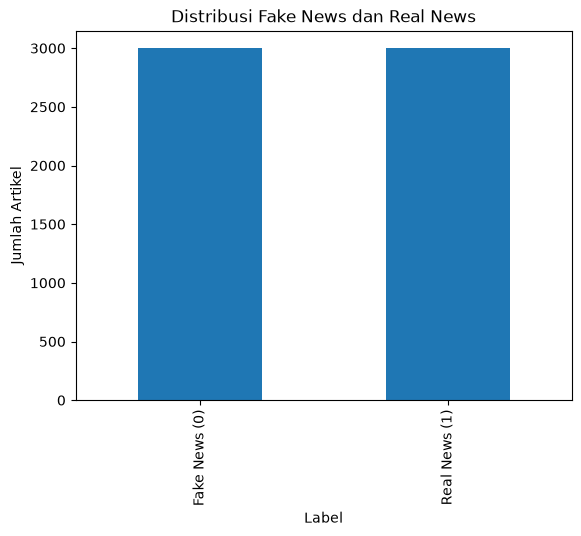

In [15]:
label_counts.plot(kind="bar")

plt.title("Distribusi Fake News dan Real News")
plt.xlabel("Label")
plt.ylabel("Jumlah Artikel")

plt.xticks(
    ticks=[0, 1],
    labels=["Fake News (0)", "Real News (1)"]
)

plt.show()

## 1.10 Analisis Distribusi Subject

Atribut `subject` menunjukkan kategori atau topik dari setiap artikel berita.

Analisis terhadap atribut ini dilakukan untuk mengetahui:

- Kategori berita yang tersedia.
- Jumlah artikel pada setiap kategori.
- Pola distribusi topik dalam dataset.

Informasi ini juga membantu menentukan apakah atribut `subject` relevan untuk digunakan sebagai fitur dalam proses pemodelan atau berpotensi menyebabkan bias terhadap hasil klasifikasi.

In [16]:
subject_counts = df["subject"].value_counts()

print(subject_counts)

subject
politicsNews       1564
worldnews          1436
News               1175
politics            870
left-news           573
Government News     185
Middle-east         100
US_News              97
Name: count, dtype: int64


## 1.11 Visualisasi Distribusi Subject

Visualisasi dilakukan menggunakan grafik batang untuk memperlihatkan jumlah artikel pada masing-masing kategori berita.

Hasil visualisasi akan membantu dalam mengidentifikasi kategori yang dominan serta memahami karakteristik distribusi topik dalam dataset.

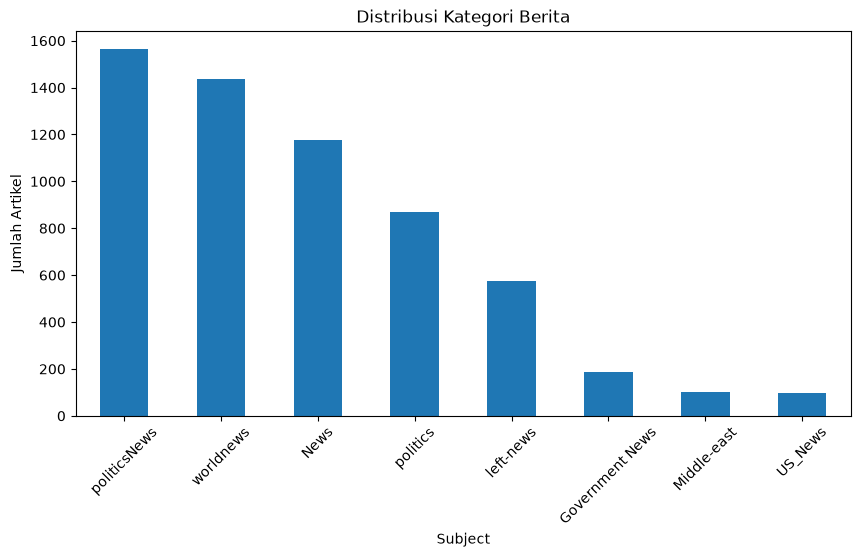

In [17]:
subject_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribusi Kategori Berita")
plt.xlabel("Subject")
plt.ylabel("Jumlah Artikel")

plt.xticks(rotation=45)

plt.show()

========================================================================================================================================

# 2. Data Preparation

Tahap Data Preparation bertujuan untuk membersihkan, mentransformasi, dan mempersiapkan dataset agar dapat digunakan dalam proses pemodelan.

Tahapan yang dilakukan meliputi:

1. Penanganan missing values dan data kosong.
2. Penghapusan data duplikat.
3. Seleksi atribut yang relevan.
4. Penggabungan atribut `title` dan `text`.
5. Pembersihan teks.
6. Text preprocessing.
7. Pembentukan fitur menggunakan TF-IDF.
8. Feature selection.

## 2.1 Penanganan Missing Values

Penanganan missing values dilakukan berdasarkan hasil pemeriksaan pada tahap Data Understanding.

Nilai yang hilang dapat memengaruhi proses pengolahan dan pemodelan data. Oleh karena itu, dilakukan pemeriksaan kembali terhadap seluruh atribut untuk memastikan bahwa dataset siap digunakan pada tahap selanjutnya.

Apabila ditemukan nilai yang hilang pada atribut penting, data akan ditangani sesuai dengan karakteristiknya.

In [5]:
print("Missing values sebelum penanganan:")
print(df.isnull().sum())

Missing values sebelum penanganan:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [6]:
df = df.dropna().copy()

print("\nMissing values setelah penanganan:")
print(df.isnull().sum())


Missing values setelah penanganan:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


## 2.2 Penanganan Empty Values

Selain nilai null, data tekstual dapat memiliki nilai kosong berupa string kosong atau whitespace.

Nilai tersebut perlu diperiksa karena tidak selalu terdeteksi sebagai missing values oleh sistem. Pemeriksaan dilakukan untuk memastikan bahwa atribut yang digunakan dalam analisis memiliki data yang valid.

In [7]:
print("Empty values sebelum penanganan:\n")

for column in df.columns:
    empty_count = df[column].fillna("").astype(str).str.strip().eq("").sum()
    print(f"{column}: {empty_count}")

Empty values sebelum penanganan:

title: 0
text: 66
subject: 0
date: 0
label: 0


## 2.3 Penanganan Empty Values

Berdasarkan hasil pemeriksaan, ditemukan sebanyak 66 nilai kosong pada atribut `text`. Sementara itu, atribut `title` tidak memiliki nilai kosong.

Karena penelitian menggunakan informasi dari judul dan isi berita, data dengan atribut `text` kosong tidak langsung dihapus. Judul berita masih mengandung informasi yang dapat digunakan dalam proses klasifikasi.

Oleh karena itu, nilai kosong pada atribut `text` ditangani dengan menggantinya menjadi string kosong. Selanjutnya, atribut `title` dan `text` akan digabungkan menjadi satu atribut baru pada tahap berikutnya.

In [9]:
df["text"] = df["text"].fillna("")
df["text"] = df["text"].astype(str).str.strip()

print("Jumlah text kosong yang tetap dipertahankan:")
print(df["text"].eq("").sum())

Jumlah text kosong yang tetap dipertahankan:
66


## 2.5 Penanganan Data Duplikat

Berdasarkan hasil pemeriksaan, terdapat 5 baris yang memiliki seluruh atribut yang sama dan 108 data yang memiliki kombinasi `title` dan `text` yang sama. Sementara itu, terdapat 116 data dengan judul yang sama.

Duplikasi berdasarkan judul saja tidak langsung dihapus karena judul yang sama belum tentu menunjukkan bahwa isi artikel juga sama. Oleh karena itu, penanganan duplikasi dilakukan berdasarkan kombinasi atribut `title` dan `text`.

Data duplikat dipertahankan satu baris dan kemunculan berikutnya dihapus.


In [10]:
# Menghapus duplicate berdasarkan title + text
df = df.drop_duplicates(
    subset=["title", "text"],
    keep="first"
).reset_index(drop=True)

print("Ukuran dataset setelah menghapus duplikat:", df.shape)

Ukuran dataset setelah menghapus duplikat: (5892, 5)


In [11]:
print("Duplicate title + text setelah penanganan:",
      df.duplicated(subset=["title", "text"]).sum())

print("Ukuran dataset:", df.shape)

Duplicate title + text setelah penanganan: 0
Ukuran dataset: (5892, 5)


## 2.6 Penggabungan Atribut Teks

Atribut `title` dan `text` merupakan sumber utama informasi tekstual dalam dataset. Oleh karena itu, kedua atribut tersebut digabungkan menjadi satu atribut baru bernama `full_text`.

Penggabungan ini dilakukan agar informasi dari judul dan isi berita dapat diproses secara bersamaan pada tahap text preprocessing dan ekstraksi fitur TF-IDF.



In [12]:
# Menggabungkan title dan text
df["full_text"] = (
    df["title"].fillna("").astype(str).str.strip()
    + " "
    + df["text"].fillna("").astype(str).str.strip()
).str.strip()

# Melihat hasil penggabungan
df[["title", "text", "full_text", "label"]].head()

,title,text,full_text,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,WATCH: Trump Just Told All The Anti-Gay Bigots...,0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,"China backs U.N. call for justice in Yemen, U....",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,Lawmakers aim to delay U.S. ceding control of ...,1


In [13]:
empty_full_text = df["full_text"].eq("").sum()

print("Jumlah full_text kosong:", empty_full_text)

Jumlah full_text kosong: 0


## 2.7 Pemeriksaan Akhir Data Preparation

Setelah dilakukan penanganan empty values, penghapusan data duplikat, dan penggabungan atribut `title` dan `text`, dilakukan pemeriksaan akhir untuk memastikan dataset siap digunakan pada tahap text preprocessing.

Pemeriksaan meliputi ukuran dataset, jumlah nilai kosong, jumlah duplikasi, serta distribusi label.


In [14]:
print("=== Pemeriksaan Akhir Dataset ===")

print("\nUkuran dataset:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nEmpty full_text:")
print(df["full_text"].eq("").sum())

print("\nDuplicate full_text:")
print(df["full_text"].duplicated().sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

=== Pemeriksaan Akhir Dataset ===

Ukuran dataset:
(5892, 6)

Missing values:
title        0
text         0
subject      0
date         0
label        0
full_text    0
dtype: int64

Empty full_text:
0

Duplicate full_text:
0

Distribusi label:
label
1    2995
0    2897
Name: count, dtype: int64


===================================================================================================================================

# 3. Text Preprocessing

Text preprocessing merupakan tahap pengolahan data teks untuk membersihkan dan menyiapkan teks sebelum digunakan dalam proses ekstraksi fitur dan klasifikasi. Pada tahap ini, atribut `full_text` yang merupakan hasil penggabungan antara `title` dan `text` akan diproses agar memiliki bentuk yang lebih konsisten dan relevan untuk analisis.

Tahapan text preprocessing yang dilakukan dalam penelitian ini meliputi:

1. **Case Folding** — mengubah seluruh teks menjadi huruf kecil.
2. **Text Cleaning** — menghapus karakter atau informasi yang tidak diperlukan, seperti URL, tanda baca, dan karakter khusus.
3. **Tokenization** — memecah teks menjadi bagian-bagian kata (*token*).
4. **Stopword Removal** — menghapus kata-kata umum yang kurang memberikan informasi terhadap proses klasifikasi.
5. **Lemmatization** — mengubah kata ke bentuk dasarnya berdasarkan konteks bahasa Inggris.

Hasil dari seluruh proses tersebut akan disimpan dalam atribut `clean_text`. Atribut ini selanjutnya digunakan sebagai input pada tahap **ekstraksi fitur TF-IDF** sebelum dilakukan proses klasifikasi menggunakan algoritma *Machine Learning*.


## 3.1 Case Folding

Case folding merupakan proses mengubah seluruh huruf pada teks menjadi huruf kecil (*lowercase*). Tahap ini dilakukan untuk menyamakan bentuk penulisan kata sehingga kata yang sama dengan penggunaan huruf kapital yang berbeda dapat dianggap sebagai kata yang sama.

Sebagai contoh, kata `Trump`, `TRUMP`, dan `trump` akan diubah menjadi `trump`. Dengan demikian, variasi penggunaan huruf kapital tidak dianggap sebagai perbedaan kata pada tahap pemrosesan teks.


In [ ]:
# Case Folding
df["case_folding"] = df["full_text"].str.lower()

# df[["full_text", "case_folding"]].head()

print("Sebelum Case Folding:")
print(df["full_text"].iloc[0])

print("\nSetelah Case Folding:")
print(df["case_folding"].iloc[0])

Sebelum Case Folding:
WATCH: Trump Just Told All The Anti-Gay Bigots And Mike Pence To Go F*ck Themselves A whole lot of evangelical Trump voters just discovered they got duped.By picking Mike Pence as his vice-president, Donald Trump sent a message to the LGBT community that their rights are in jeopardy of being rolled back.In fact, one of the reasons why so many conservative  Christians  tossed their alleged  morality  out the window to vote for him was precisely because they believed he would pass a constitutional amendment banning same-sex marriage or pack the courts with anti-gay bigots to strike down all the rulings in favor of marriage equality.But during his interview on 60 minutes with Leslie Stahl on Sunday night, Trump once again backed off another campaign promise. Do you support marriage equality?  Stahl asked Trump. It s irrelevant because it s already settled,  Trump replied.  It s law. It was settled in the Supreme Court. I mean, it s done. When Stahl pointed out that T

## 3.2 Text Cleaning

Text cleaning merupakan proses membersihkan teks dari elemen-elemen yang tidak diperlukan dalam proses analisis. Pada tahap ini, teks hasil *case folding* akan dibersihkan dari URL, tanda baca (*punctuation*), angka, serta karakter khusus.

Proses ini bertujuan untuk mengurangi noise pada data teks sehingga informasi yang digunakan pada tahap berikutnya lebih relevan untuk proses ekstraksi fitur dan klasifikasi.


In [18]:
import re

def clean_text(text):
    # Menghapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Menghapus angka
    text = re.sub(r"\d+", "", text)
    
    # Menghapus tanda baca dan karakter khusus
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["case_folding"].apply(clean_text)

# Menampilkan hasil
df[["case_folding", "clean_text"]].head()

,case_folding,clean_text
0,watch: trump just told all the anti-gay bigots...,watch trump just told all the anti gay bigots ...
1,"china backs u.n. call for justice in yemen, u....",china backs u n call for justice in yemen u s ...
2,the people’s president: trump meets with coal ...,the people s president trump meets with coal w...
3,wsj reporter rips into dem candidates for thei...,wsj reporter rips into dem candidates for thei...
4,lawmakers aim to delay u.s. ceding control of ...,lawmakers aim to delay u s ceding control of i...


In [19]:
print("Sebelum Text Cleaning:")
print(df["case_folding"].iloc[0])

print("\nSetelah Text Cleaning:")
print(df["clean_text"].iloc[0])

Sebelum Text Cleaning:
watch: trump just told all the anti-gay bigots and mike pence to go f*ck themselves a whole lot of evangelical trump voters just discovered they got duped.by picking mike pence as his vice-president, donald trump sent a message to the lgbt community that their rights are in jeopardy of being rolled back.in fact, one of the reasons why so many conservative  christians  tossed their alleged  morality  out the window to vote for him was precisely because they believed he would pass a constitutional amendment banning same-sex marriage or pack the courts with anti-gay bigots to strike down all the rulings in favor of marriage equality.but during his interview on 60 minutes with leslie stahl on sunday night, trump once again backed off another campaign promise. do you support marriage equality?  stahl asked trump. it s irrelevant because it s already settled,  trump replied.  it s law. it was settled in the supreme court. i mean, it s done. when stahl pointed out that 

## 3.3 Tokenization

Tokenization merupakan proses memecah teks menjadi unit-unit yang lebih kecil yang disebut *token*. Dalam penelitian ini, teks akan dipecah berdasarkan kata sehingga setiap kata dapat diproses secara individual pada tahap preprocessing berikutnya.

Sebagai contoh, teks `watch trump just told the people` akan diubah menjadi beberapa token, yaitu `watch`, `trump`, `just`, `told`, `the`, dan `people`.

Proses tokenization dilakukan setelah text cleaning sehingga teks yang akan dipecah telah terbebas dari sebagian besar karakter dan simbol yang tidak diperlukan.


In [21]:
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer jika belum tersedia
nltk.download("punkt")
nltk.download("punkt_tab")

# Tokenization
df["tokens"] = df["clean_text"].apply(word_tokenize)

# Menampilkan hasil tokenization
df[["clean_text", "tokens"]].head()

[nltk_data] Downloading package punkt to C:\Users\HP
[nltk_data]     Leptop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP
[nltk_data]     Leptop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,clean_text,tokens
0,watch trump just told all the anti gay bigots ...,"[watch, trump, just, told, all, the, anti, gay..."
1,china backs u n call for justice in yemen u s ...,"[china, backs, u, n, call, for, justice, in, y..."
2,the people s president trump meets with coal w...,"[the, people, s, president, trump, meets, with..."
3,wsj reporter rips into dem candidates for thei...,"[wsj, reporter, rips, into, dem, candidates, f..."
4,lawmakers aim to delay u s ceding control of i...,"[lawmakers, aim, to, delay, u, s, ceding, cont..."


In [22]:
print("Sebelum Tokenization:")
print(df["clean_text"].iloc[0])

print("\nSetelah Tokenization:")
print(df["tokens"].iloc[0])

Sebelum Tokenization:
watch trump just told all the anti gay bigots and mike pence to go f ck themselves a whole lot of evangelical trump voters just discovered they got duped by picking mike pence as his vice president donald trump sent a message to the lgbt community that their rights are in jeopardy of being rolled back in fact one of the reasons why so many conservative christians tossed their alleged morality out the window to vote for him was precisely because they believed he would pass a constitutional amendment banning same sex marriage or pack the courts with anti gay bigots to strike down all the rulings in favor of marriage equality but during his interview on minutes with leslie stahl on sunday night trump once again backed off another campaign promise do you support marriage equality stahl asked trump it s irrelevant because it s already settled trump replied it s law it was settled in the supreme court i mean it s done when stahl pointed out that trump s supreme court no

## 3.4 Stopword Removal

Stopword removal merupakan proses menghapus kata-kata umum yang memiliki frekuensi tinggi tetapi umumnya tidak memberikan informasi yang signifikan terhadap proses klasifikasi teks. Contoh stopword dalam bahasa Inggris adalah `the`, `is`, `and`, `of`, `to`, dan `in`.

Penghapusan stopword dilakukan untuk mengurangi jumlah kata yang perlu diproses serta membantu mempertahankan kata-kata yang lebih informatif untuk proses ekstraksi fitur dan klasifikasi.


In [23]:
from nltk.corpus import stopwords

# Download English stopwords jika belum tersedia
nltk.download("stopwords")

# Membuat daftar stopword bahasa Inggris
stop_words = set(stopwords.words("english"))

# Menghapus stopword
df["tokens_clean"] = df["tokens"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

# Menampilkan hasil
df[["tokens", "tokens_clean"]].head()

[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     Leptop\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,tokens,tokens_clean
0,"[watch, trump, just, told, all, the, anti, gay...","[watch, trump, told, anti, gay, bigots, mike, ..."
1,"[china, backs, u, n, call, for, justice, in, y...","[china, backs, u, n, call, justice, yemen, u, ..."
2,"[the, people, s, president, trump, meets, with...","[people, president, trump, meets, coal, worker..."
3,"[wsj, reporter, rips, into, dem, candidates, f...","[wsj, reporter, rips, dem, candidates, lame, r..."
4,"[lawmakers, aim, to, delay, u, s, ceding, cont...","[lawmakers, aim, delay, u, ceding, control, in..."


In [24]:
print("Sebelum Stopword Removal:")
print(df["tokens"].iloc[0])

print("\nSetelah Stopword Removal:")
print(df["tokens_clean"].iloc[0])

Sebelum Stopword Removal:
['watch', 'trump', 'just', 'told', 'all', 'the', 'anti', 'gay', 'bigots', 'and', 'mike', 'pence', 'to', 'go', 'f', 'ck', 'themselves', 'a', 'whole', 'lot', 'of', 'evangelical', 'trump', 'voters', 'just', 'discovered', 'they', 'got', 'duped', 'by', 'picking', 'mike', 'pence', 'as', 'his', 'vice', 'president', 'donald', 'trump', 'sent', 'a', 'message', 'to', 'the', 'lgbt', 'community', 'that', 'their', 'rights', 'are', 'in', 'jeopardy', 'of', 'being', 'rolled', 'back', 'in', 'fact', 'one', 'of', 'the', 'reasons', 'why', 'so', 'many', 'conservative', 'christians', 'tossed', 'their', 'alleged', 'morality', 'out', 'the', 'window', 'to', 'vote', 'for', 'him', 'was', 'precisely', 'because', 'they', 'believed', 'he', 'would', 'pass', 'a', 'constitutional', 'amendment', 'banning', 'same', 'sex', 'marriage', 'or', 'pack', 'the', 'courts', 'with', 'anti', 'gay', 'bigots', 'to', 'strike', 'down', 'all', 'the', 'rulings', 'in', 'favor', 'of', 'marriage', 'equality', 'but',

## 3.5 Lemmatization

Lemmatization merupakan proses mengubah kata ke bentuk dasarnya (*lemma*) berdasarkan aturan dan konteks bahasa. Proses ini bertujuan untuk menyamakan berbagai bentuk kata yang memiliki makna dasar yang sama sehingga jumlah variasi kata dalam data dapat dikurangi.

Sebagai contoh, kata `running`, `runs`, dan `ran` dapat dinormalisasi menjadi bentuk dasar `run`. Dengan demikian, kata-kata yang memiliki hubungan secara morfologis dapat diperlakukan secara lebih konsisten dalam proses analisis teks.


In [25]:
from nltk.stem import WordNetLemmatizer

# Download resource WordNet jika belum tersedia
nltk.download("wordnet")
nltk.download("omw-1.4")

# Membuat lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatization
df["lemmatized_tokens"] = df["tokens_clean"].apply(
    lambda tokens: [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
)

# Menampilkan hasil
df[["tokens_clean", "lemmatized_tokens"]].head()

[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     Leptop\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\HP
[nltk_data]     Leptop\AppData\Roaming\nltk_data...


,tokens_clean,lemmatized_tokens
0,"[watch, trump, told, anti, gay, bigots, mike, ...","[watch, trump, told, anti, gay, bigot, mike, p..."
1,"[china, backs, u, n, call, justice, yemen, u, ...","[china, back, u, n, call, justice, yemen, u, s..."
2,"[people, president, trump, meets, coal, worker...","[people, president, trump, meet, coal, worker,..."
3,"[wsj, reporter, rips, dem, candidates, lame, r...","[wsj, reporter, rip, dem, candidate, lame, rhe..."
4,"[lawmakers, aim, delay, u, ceding, control, in...","[lawmaker, aim, delay, u, ceding, control, int..."


In [26]:
print("Sebelum Lemmatization:")
print(df["tokens_clean"].iloc[0])

print("\nSetelah Lemmatization:")
print(df["lemmatized_tokens"].iloc[0])

Sebelum Lemmatization:
['watch', 'trump', 'told', 'anti', 'gay', 'bigots', 'mike', 'pence', 'go', 'f', 'ck', 'whole', 'lot', 'evangelical', 'trump', 'voters', 'discovered', 'got', 'duped', 'picking', 'mike', 'pence', 'vice', 'president', 'donald', 'trump', 'sent', 'message', 'lgbt', 'community', 'rights', 'jeopardy', 'rolled', 'back', 'fact', 'one', 'reasons', 'many', 'conservative', 'christians', 'tossed', 'alleged', 'morality', 'window', 'vote', 'precisely', 'believed', 'would', 'pass', 'constitutional', 'amendment', 'banning', 'sex', 'marriage', 'pack', 'courts', 'anti', 'gay', 'bigots', 'strike', 'rulings', 'favor', 'marriage', 'equality', 'interview', 'minutes', 'leslie', 'stahl', 'sunday', 'night', 'trump', 'backed', 'another', 'campaign', 'promise', 'support', 'marriage', 'equality', 'stahl', 'asked', 'trump', 'irrelevant', 'already', 'settled', 'trump', 'replied', 'law', 'settled', 'supreme', 'court', 'mean', 'done', 'stahl', 'pointed', 'trump', 'supreme', 'court', 'nominees', 

## 3.6 Final Text Preparation

Setelah melalui proses case folding, text cleaning, tokenization, stopword removal, dan lemmatization, token yang telah diproses perlu digabungkan kembali menjadi teks utuh.

Pada tahap ini, setiap token hasil lemmatization digabungkan menggunakan spasi dan disimpan dalam atribut `final_text`. Atribut tersebut merupakan hasil akhir dari proses text preprocessing dan akan digunakan sebagai input pada tahap ekstraksi fitur menggunakan TF-IDF.


In [27]:
# Menggabungkan kembali token hasil lemmatization menjadi teks
df["final_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

# Menampilkan hasil akhir preprocessing
df[["full_text", "final_text", "label"]].head()

,full_text,final_text,label
0,WATCH: Trump Just Told All The Anti-Gay Bigots...,watch trump told anti gay bigot mike penny go ...,0
1,"China backs U.N. call for justice in Yemen, U....",china back u n call justice yemen u saudi gene...,1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,people president trump meet coal worker fulfil...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,wsj reporter rip dem candidate lame rhetoric i...,0
4,Lawmakers aim to delay U.S. ceding control of ...,lawmaker aim delay u ceding control internet m...,1


In [28]:
print("Sebelum preprocessing:")
print(df["full_text"].iloc[0])

print("\nSetelah preprocessing:")
print(df["final_text"].iloc[0])

Sebelum preprocessing:
WATCH: Trump Just Told All The Anti-Gay Bigots And Mike Pence To Go F*ck Themselves A whole lot of evangelical Trump voters just discovered they got duped.By picking Mike Pence as his vice-president, Donald Trump sent a message to the LGBT community that their rights are in jeopardy of being rolled back.In fact, one of the reasons why so many conservative  Christians  tossed their alleged  morality  out the window to vote for him was precisely because they believed he would pass a constitutional amendment banning same-sex marriage or pack the courts with anti-gay bigots to strike down all the rulings in favor of marriage equality.But during his interview on 60 minutes with Leslie Stahl on Sunday night, Trump once again backed off another campaign promise. Do you support marriage equality?  Stahl asked Trump. It s irrelevant because it s already settled,  Trump replied.  It s law. It was settled in the Supreme Court. I mean, it s done. When Stahl pointed out that 

In [29]:
print("Jumlah final_text kosong:",
      df["final_text"].eq("").sum())

print("Jumlah data:",
      len(df))

Jumlah final_text kosong: 1
Jumlah data: 5892


In [30]:
empty_final = df[df["final_text"].eq("")]

print("Jumlah final_text kosong:", len(empty_final))

empty_final[[
    "title",
    "text",
    "full_text",
    "case_folding",
    "clean_text",
    "tokens",
    "tokens_clean",
    "lemmatized_tokens",
    "final_text",
    "label"
]]

Jumlah final_text kosong: 1


,title,text,full_text,case_folding,clean_text,tokens,tokens_clean,lemmatized_tokens,final_text,label
4830,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,,[],[],[],,0


## 3.7 Penanganan Data Tanpa Informasi Tekstual

Setelah seluruh tahapan text preprocessing dilakukan, ditemukan satu data yang menghasilkan `final_text` kosong. Setelah dilakukan pemeriksaan, diketahui bahwa atribut `title` dan `text` pada data tersebut hanya berisi URL menuju gambar.

Karena URL tersebut dihapus pada tahap text cleaning dan tidak terdapat informasi tekstual lain yang dapat digunakan untuk proses klasifikasi, data tersebut tidak memiliki fitur teks yang relevan.

Oleh karena itu, satu data tersebut dihapus dari dataset sehingga seluruh data yang digunakan pada tahap ekstraksi fitur memiliki informasi tekstual yang dapat diproses.


In [31]:
# Menghapus data yang tidak memiliki informasi tekstual
df = df[df["final_text"].str.strip() != ""].reset_index(drop=True)

print("Ukuran dataset setelah penanganan:", df.shape)
print("Jumlah final_text kosong:", df["final_text"].eq("").sum())

Ukuran dataset setelah penanganan: (5891, 12)
Jumlah final_text kosong: 0


In [32]:
print("=== Kondisi Dataset Setelah Text Preprocessing ===")

print("\nUkuran dataset:")
print(df.shape)

print("\nFinal text kosong:")
print(df["final_text"].eq("").sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

print("\nPersentase label:")
print(df["label"].value_counts(normalize=True) * 100)

=== Kondisi Dataset Setelah Text Preprocessing ===

Ukuran dataset:
(5891, 12)

Final text kosong:
0

Distribusi label:
label
1    2995
0    2896
Name: count, dtype: int64

Persentase label:
label
1    50.840265
0    49.159735
Name: proportion, dtype: float64


=================================================================================================================================================================

## 4. Feature Extraction

Setelah proses text preprocessing selesai, data teks yang telah dibersihkan perlu diubah menjadi bentuk numerik agar dapat digunakan oleh algoritma Machine Learning.

Pada penelitian ini digunakan metode **Term Frequency-Inverse Document Frequency (TF-IDF)** untuk melakukan feature extraction.

TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam dokumen. Kata yang sering muncul pada suatu dokumen tetapi jarang muncul pada dokumen lain akan memperoleh bobot yang lebih tinggi.

Tahapan feature extraction menggunakan TF-IDF dilakukan dengan memanfaatkan kolom `final_text` yang telah dihasilkan pada tahap preprocessing.


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Mengubah teks menjadi matriks TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform(df["final_text"])

print("Ukuran matriks TF-IDF:", tfidf_matrix.shape)

Ukuran matriks TF-IDF: (5891, 42963)


### 4.2 Pemeriksaan Fitur TF-IDF

Setelah proses transformasi teks menggunakan TF-IDF, dilakukan pemeriksaan terhadap fitur yang telah terbentuk. Pemeriksaan ini bertujuan untuk mengetahui jumlah fitur yang dihasilkan serta melihat contoh vocabulary yang digunakan dalam representasi teks.

Selain itu, beberapa nilai dari matriks TF-IDF ditampilkan sebagai contoh untuk memastikan bahwa data teks telah berhasil diubah menjadi representasi numerik.

Jumlah fitur yang dihasilkan pada tahap TF-IDF adalah **42.963 fitur** dari **5.891 artikel**. Dengan demikian, setiap artikel direpresentasikan menggunakan bobot TF-IDF berdasarkan fitur-fitur yang terdapat dalam vocabulary.

Pemeriksaan ini dilakukan sebelum data digunakan pada tahap pembagian data menjadi **data training** dan **data testing**.


In [34]:
# Mendapatkan vocabulary dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Jumlah fitur:", len(feature_names))

print("\n10 fitur pertama:")
print(feature_names[:10])

Jumlah fitur: 42963

10 fitur pertama:
['aa' 'aaa' 'aaaand' 'aab' 'aaba' 'aabo' 'aacnrxomr' 'aadhaar' 'aadhar'
 'aaja']


In [35]:
# Menampilkan sebagian kecil matriks TF-IDF
tfidf_matrix[:5, :10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

### 4.3 Persiapan Data untuk Machine Learning

Setelah teks berhasil diubah menjadi matriks TF-IDF, data perlu dipisahkan menjadi **fitur (X)** dan **target (y)**.

Fitur (X) berupa matriks TF-IDF yang berisi bobot dari setiap kata pada masing-masing artikel. Sementara itu, target (y) berupa kolom `label` yang menunjukkan kelas berita, yaitu **0 untuk Fake News** dan **1 untuk Real News**.

Pemisahan ini dilakukan agar data dapat digunakan pada tahap berikutnya, yaitu pembagian dataset menjadi data training dan data testing.


In [36]:
# Menyiapkan fitur (X) dan target (y)

X = tfidf_matrix
y = df["label"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (5891, 42963)
Ukuran y: (5891,)


### 4.4 Pembagian Data Training dan Testing

Dataset kemudian dibagi menjadi dua bagian, yaitu **data training** dan **data testing**. Data training digunakan untuk melatih model Machine Learning, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan klasifikasi terhadap data yang belum pernah dilihat sebelumnya.

Pada penelitian ini digunakan pembagian **80% data training dan 20% data testing**. Parameter `stratify` digunakan agar proporsi masing-masing kelas pada data training dan testing tetap mendekati distribusi kelas pada dataset keseluruhan.


In [37]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (4712, 42963)
Ukuran X_test : (1179, 42963)
Ukuran y_train: (4712,)
Ukuran y_test : (1179,)


In [38]:
print("Distribusi label pada data training:")
print(y_train.value_counts())

print("\nDistribusi label pada data testing:")
print(y_test.value_counts())

Distribusi label pada data training:
label
1    2396
0    2316
Name: count, dtype: int64

Distribusi label pada data testing:
label
1    599
0    580
Name: count, dtype: int64


================================================================================================================================================================

## 5. Pemodelan Machine Learning

Setelah data teks berhasil direpresentasikan menggunakan TF-IDF dan dibagi menjadi data training dan testing, tahap selanjutnya adalah membangun model Machine Learning untuk melakukan klasifikasi berita.

Model yang digunakan bertujuan untuk memprediksi apakah suatu artikel termasuk **Fake News (label 0)** atau **Real News (label 1)**.

Pada tahap awal digunakan **Logistic Regression** sebagai model baseline. Logistic Regression merupakan salah satu algoritma klasifikasi yang sesuai untuk data berdimensi tinggi seperti representasi teks menggunakan TF-IDF.

Model akan dilatih menggunakan data training dan kemudian digunakan untuk melakukan prediksi terhadap data testing.


In [39]:
from sklearn.linear_model import LogisticRegression

# Membuat model Logistic Regression
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Melatih model menggunakan data training
model_lr.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


### 5.2 Prediksi Data Testing

Setelah model Logistic Regression berhasil dilatih menggunakan data training, tahap selanjutnya adalah melakukan prediksi terhadap data testing.

Data testing digunakan untuk mengetahui kemampuan model dalam mengklasifikasikan artikel yang belum pernah digunakan selama proses pelatihan. Hasil prediksi kemudian akan dibandingkan dengan label sebenarnya untuk mengukur performa model.


In [40]:
# Melakukan prediksi pada data testing
y_pred = model_lr.predict(X_test)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 1179


### 5.3 Evaluasi Model

Setelah memperoleh hasil prediksi dari data testing, performa model Logistic Regression perlu dievaluasi menggunakan beberapa metrik klasifikasi.

Metrik yang digunakan adalah **Accuracy, Precision, Recall, dan F1-Score**. Keempat metrik tersebut digunakan untuk memberikan gambaran mengenai kemampuan model dalam mengklasifikasikan berita Fake News dan Real News.

* **Accuracy** menunjukkan persentase keseluruhan prediksi yang benar.
* **Precision** menunjukkan ketepatan model ketika memprediksi suatu kelas.
* **Recall** menunjukkan kemampuan model dalam menemukan data yang termasuk ke dalam suatu kelas.
* **F1-Score** merupakan rata-rata harmonik antara Precision dan Recall.

Evaluasi dilakukan dengan membandingkan label hasil prediksi dengan label sebenarnya pada data testing.


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Hasil Evaluasi Logistic Regression ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

=== Hasil Evaluasi Logistic Regression ===
Accuracy  : 0.9695
Precision : 0.9562
Recall    : 0.9850
F1-Score  : 0.9704


### 5.4 Classification Report

Selain menggunakan Accuracy, Precision, Recall, dan F1-Score secara keseluruhan, evaluasi juga dilakukan menggunakan **Classification Report**.

Classification Report memberikan nilai Precision, Recall, dan F1-Score untuk masing-masing kelas, yaitu **Fake News (0)** dan **Real News (1)**. Dengan demikian, performa model dapat dianalisis secara lebih detail untuk setiap kategori berita.


In [42]:
from sklearn.metrics import classification_report

# Menampilkan classification report
print("=== Classification Report ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake News", "Real News"]
    )
)

=== Classification Report ===
              precision    recall  f1-score   support

   Fake News       0.98      0.95      0.97       580
   Real News       0.96      0.98      0.97       599

    accuracy                           0.97      1179
   macro avg       0.97      0.97      0.97      1179
weighted avg       0.97      0.97      0.97      1179



### 5.5 Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas. Dengan Confusion Matrix, dapat diketahui secara lebih rinci jumlah **True Positive (TP)**, **True Negative (TN)**, **False Positive (FP)**, dan **False Negative (FN)** yang dihasilkan oleh model.

Dalam penelitian ini, Confusion Matrix digunakan untuk mengetahui kemampuan Logistic Regression dalam membedakan **Fake News (0)** dan **Real News (1)** pada data testing.


In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("=== Confusion Matrix ===")
print(cm)

=== Confusion Matrix ===
[[553  27]
 [  9 590]]


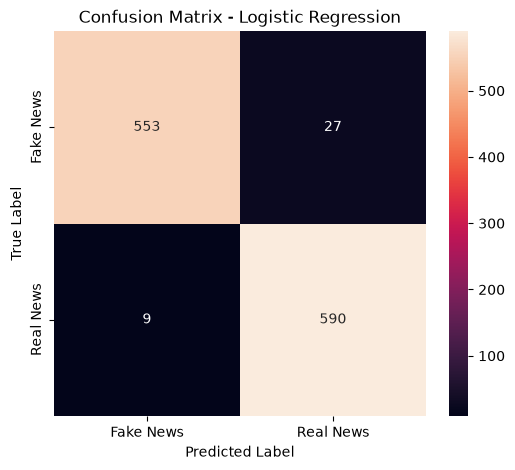

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake News", "Real News"],
    yticklabels=["Fake News", "Real News"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 5.6 Interpretasi Confusion Matrix

Berdasarkan Confusion Matrix, model Logistic Regression berhasil mengklasifikasikan **553 artikel Fake News** dengan benar dan **590 artikel Real News** dengan benar.

Model juga melakukan kesalahan klasifikasi terhadap **27 artikel Fake News** yang diprediksi sebagai Real News dan **9 artikel Real News** yang diprediksi sebagai Fake News.

Dengan demikian, dari total **1.179 artikel pada data testing**, sebanyak **1.143 artikel berhasil diklasifikasikan dengan benar**, sedangkan **36 artikel mengalami kesalahan klasifikasi**.

Hasil tersebut menunjukkan bahwa model Logistic Regression memiliki kemampuan yang sangat baik dalam membedakan Fake News dan Real News berdasarkan fitur TF-IDF.


=======================================================================================================================================================

## 6. Pemodelan dengan Naive Bayes

Selain Logistic Regression, penelitian ini menggunakan algoritma **Naive Bayes** sebagai model pembanding.

Jenis Naive Bayes yang digunakan adalah **Multinomial Naive Bayes**, yang sesuai untuk permasalahan klasifikasi teks dengan fitur berbasis TF-IDF. Model ini menggunakan probabilitas kemunculan fitur untuk menentukan kelas dari suatu dokumen.

Pada tahap ini, model Multinomial Naive Bayes dilatih menggunakan data training yang telah direpresentasikan dalam bentuk TF-IDF. Selanjutnya, model digunakan untuk melakukan klasifikasi terhadap data testing.


## 6.1 Melatih Model

In [46]:
from sklearn.naive_bayes import MultinomialNB

# Membuat model Multinomial Naive Bayes
model_nb = MultinomialNB()

# Melatih model menggunakan data training
model_nb.fit(X_train, y_train)

print("Model Multinomial Naive Bayes berhasil dilatih.")

Model Multinomial Naive Bayes berhasil dilatih.


### 6.2 Prediksi Data Testing

Setelah model Multinomial Naive Bayes berhasil dilatih menggunakan data training, model digunakan untuk melakukan prediksi terhadap data testing.

Hasil prediksi kemudian akan dibandingkan dengan label sebenarnya untuk mengetahui kemampuan model dalam mengklasifikasikan artikel ke dalam kelas **Fake News (0)** dan **Real News (1)**.


In [47]:
# Melakukan prediksi pada data testing
y_pred_nb = model_nb.predict(X_test)

print("Prediksi Naive Bayes berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_nb))

Prediksi Naive Bayes berhasil dilakukan.
Jumlah data yang diprediksi: 1179


### 6.3 Evaluasi Model Naive Bayes

Setelah model Multinomial Naive Bayes melakukan prediksi terhadap data testing, tahap selanjutnya adalah mengevaluasi performa model.

Evaluasi dilakukan menggunakan **Accuracy, Precision, Recall, dan F1-Score**. Penggunaan metrik yang sama dengan model Logistic Regression bertujuan agar kedua model dapat dibandingkan secara objektif berdasarkan performa klasifikasinya.


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Menghitung metrik evaluasi Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("=== Hasil Evaluasi Naive Bayes ===")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")

=== Hasil Evaluasi Naive Bayes ===
Accuracy  : 0.9211
Precision : 0.8941
Recall    : 0.9583
F1-Score  : 0.9251


### 6.4 Classification Report

Untuk memperoleh evaluasi yang lebih terperinci, model Multinomial Naive Bayes dievaluasi menggunakan Classification Report.

Classification Report menampilkan nilai Precision, Recall, dan F1-Score untuk masing-masing kelas, yaitu **Fake News (0)** dan **Real News (1)**. Hasil ini digunakan untuk melihat kemampuan model dalam mengenali setiap kategori berita secara lebih spesifik.


In [49]:
from sklearn.metrics import classification_report

# Menampilkan classification report
print("=== Classification Report Naive Bayes ===")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Fake News", "Real News"]
    )
)

=== Classification Report Naive Bayes ===
              precision    recall  f1-score   support

   Fake News       0.95      0.88      0.92       580
   Real News       0.89      0.96      0.93       599

    accuracy                           0.92      1179
   macro avg       0.92      0.92      0.92      1179
weighted avg       0.92      0.92      0.92      1179



### Interpretasi Classification Report

Berdasarkan Classification Report, model Multinomial Naive Bayes memperoleh **Accuracy sebesar 92%**. Pada kelas Fake News, model memperoleh Precision sebesar **95%**, Recall sebesar **88%**, dan F1-Score sebesar **92%**. Sementara itu, pada kelas Real News diperoleh Precision sebesar **89%**, Recall sebesar **96%**, dan F1-Score sebesar **93%**.

Hasil tersebut menunjukkan bahwa model memiliki kemampuan yang lebih baik dalam mengenali Real News dibandingkan Fake News. Hal ini terlihat dari nilai Recall Real News yang mencapai 96%, sedangkan Recall Fake News hanya sebesar 88%.

Jika dibandingkan dengan Logistic Regression, Naive Bayes memiliki performa yang lebih rendah pada seluruh metrik utama. Oleh karena itu, berdasarkan hasil sementara, **Logistic Regression menunjukkan performa yang lebih baik untuk dataset Fake News Detection ini**.


### 6.5 Confusion Matrix

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar dan salah pada masing-masing kelas yang dihasilkan oleh model Multinomial Naive Bayes.

Hasil Confusion Matrix akan menunjukkan jumlah Fake News dan Real News yang berhasil diklasifikasikan dengan benar maupun yang mengalami kesalahan klasifikasi.


In [50]:
from sklearn.metrics import confusion_matrix

# Membuat confusion matrix Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("=== Confusion Matrix Naive Bayes ===")
print(cm_nb)

=== Confusion Matrix Naive Bayes ===
[[512  68]
 [ 25 574]]


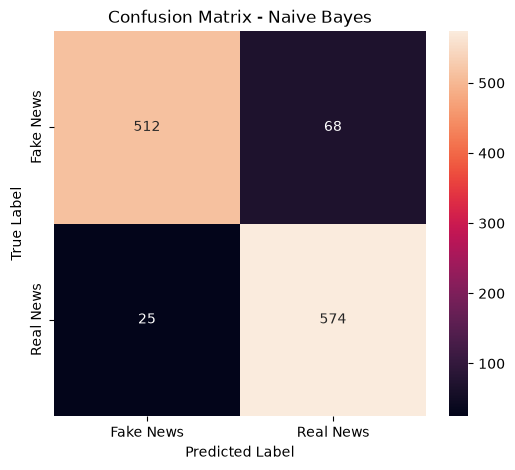

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Fake News", "Real News"],
    yticklabels=["Fake News", "Real News"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

### 6.6 Interpretasi Confusion Matrix

Berdasarkan Confusion Matrix, model Multinomial Naive Bayes berhasil mengklasifikasikan **512 artikel Fake News** dan **574 artikel Real News** dengan benar.

Sementara itu, terdapat **68 artikel Fake News** yang salah diprediksi sebagai Real News dan **25 artikel Real News** yang salah diprediksi sebagai Fake News.

Dari total **1.179 artikel pada data testing**, model berhasil melakukan klasifikasi dengan benar terhadap **1.086 artikel**, sedangkan **93 artikel mengalami kesalahan klasifikasi**.

Jika dibandingkan dengan Logistic Regression, Naive Bayes menghasilkan jumlah kesalahan klasifikasi yang lebih banyak. Hal ini sejalan dengan nilai Accuracy, Precision, Recall, dan F1-Score yang lebih rendah.


===================================================================================================================================================

## 7. Pemodelan dengan Linear Support Vector Machine (SVM)

Linear Support Vector Machine (SVM) merupakan salah satu algoritma klasifikasi yang banyak digunakan pada permasalahan klasifikasi teks. SVM bekerja dengan mencari batas pemisah (*hyperplane*) yang optimal antara dua kelas.

Pada penelitian ini, Linear SVM digunakan untuk mengklasifikasikan berita menjadi dua kelas, yaitu **Fake News (0)** dan **Real News (1)** berdasarkan fitur TF-IDF yang telah diperoleh pada tahap sebelumnya.

Model yang digunakan adalah `LinearSVC` karena dirancang untuk bekerja secara efisien pada data berdimensi tinggi seperti matriks TF-IDF.


## 7.1 Melatih Model Linear SVM

In [52]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(
    random_state=42
)

model_svm.fit(X_train, y_train)

print("Model Linear SVM berhasil dilatih.")

Model Linear SVM berhasil dilatih.


## 7.2 Melakukan Prediksi

In [53]:
y_pred_svm = model_svm.predict(X_test)

print("Prediksi Linear SVM berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_svm))

Prediksi Linear SVM berhasil dilakukan.
Jumlah data yang diprediksi: 1179


## 7.3 Evaluasi Linear SVM

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("=== Hasil Evaluasi Linear SVM ===")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")

=== Hasil Evaluasi Linear SVM ===
Accuracy  : 0.9856
Precision : 0.9786
Recall    : 0.9933
F1-Score  : 0.9859


### 7.4 Classification Report

Classification report digunakan untuk melihat performa Linear SVM pada masing-masing kelas, yaitu Fake News dan Real News. Evaluasi mencakup nilai precision, recall, dan F1-score untuk setiap kelas.


In [55]:
from sklearn.metrics import classification_report

print("=== Classification Report Linear SVM ===")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Fake News", "Real News"]
    )
)

=== Classification Report Linear SVM ===
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.99       580
   Real News       0.98      0.99      0.99       599

    accuracy                           0.99      1179
   macro avg       0.99      0.99      0.99      1179
weighted avg       0.99      0.99      0.99      1179



## 7.5 Confusion Matrix

In [56]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("=== Confusion Matrix Linear SVM ===")
print(cm_svm)

=== Confusion Matrix Linear SVM ===
[[567  13]
 [  4 595]]


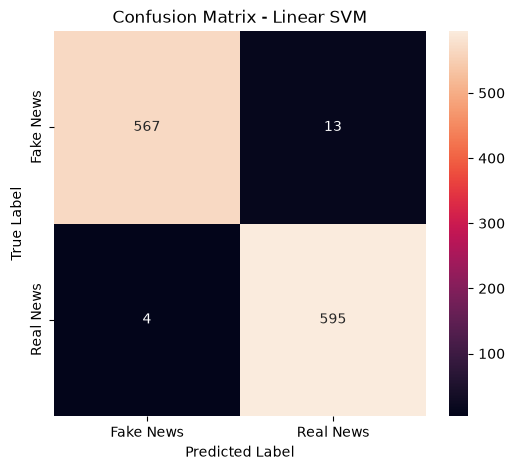

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Fake News", "Real News"],
    yticklabels=["Fake News", "Real News"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

### 7.7 Interpretasi Confusion Matrix

Berdasarkan confusion matrix, Linear SVM berhasil mengklasifikasikan **567 berita Fake News** dan **595 berita Real News** dengan benar. Sementara itu, terdapat **13 berita Fake News** yang diklasifikasikan sebagai Real News dan **4 berita Real News** yang diklasifikasikan sebagai Fake News.

Dari total **1.179 data pengujian**, sebanyak **1.162 data berhasil diklasifikasikan dengan benar**, sedangkan hanya **17 data yang mengalami kesalahan klasifikasi**. Hasil tersebut menunjukkan bahwa Linear SVM memiliki performa klasifikasi yang sangat baik pada dataset yang digunakan.


========================================================================================================================================================

## 8. Perbandingan Model

Setelah dilakukan pelatihan dan evaluasi terhadap tiga algoritma, yaitu Logistic Regression, Multinomial Naive Bayes, dan Linear SVM, tahap selanjutnya adalah membandingkan performa masing-masing model.

Perbandingan dilakukan berdasarkan empat metrik evaluasi, yaitu Accuracy, Precision, Recall, dan F1-Score. Model dengan nilai evaluasi yang lebih tinggi menunjukkan performa klasifikasi yang lebih baik pada dataset Fake News Detection.


## 8.1 Tabel Perbadingan

In [59]:
# Membuat tabel perbandingan performa ketiga model

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_svm
    ],
    "F1-Score": [
        f1,
        f1_nb,
        f1_svm
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.969466,0.956240,0.984975,0.970395
1,Naive Bayes,0.921120,0.894081,0.958264,0.925060
2,Linear SVM,0.985581,0.978618,0.993322,0.985915


## 8.2 Visualisasi Perbandingan

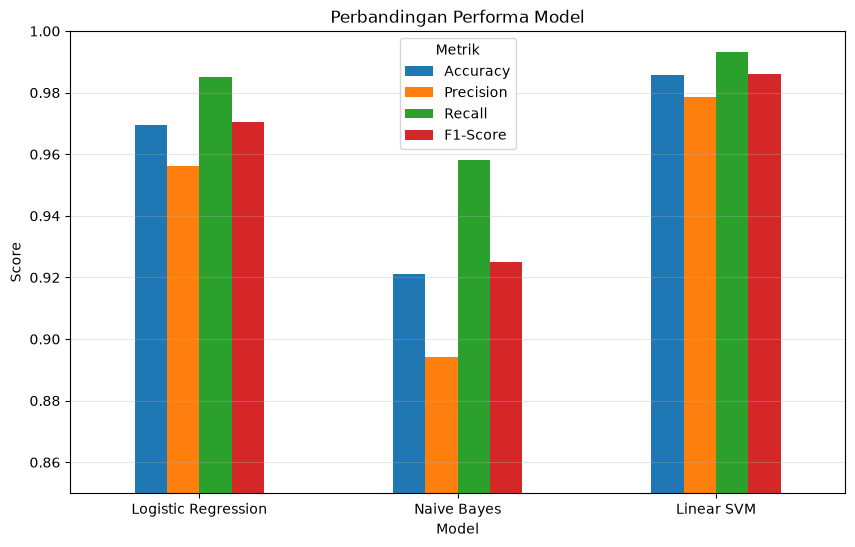

In [60]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 8.3 Kesimpulan Perbandingan Model

Berdasarkan hasil evaluasi, **Linear SVM menunjukkan performa terbaik** dibandingkan Logistic Regression dan Multinomial Naive Bayes.

Linear SVM memperoleh **Accuracy sebesar 98.56%**, **Precision sebesar 97.86%**, **Recall sebesar 99.33%**, dan **F1-Score sebesar 98.59%**. Nilai tersebut merupakan yang tertinggi pada seluruh metrik evaluasi.

Logistic Regression berada pada posisi kedua dengan Accuracy sebesar 96.95%, sedangkan Multinomial Naive Bayes memperoleh Accuracy sebesar 92.11%.

Dengan demikian, **Linear SVM dipilih sebagai model terbaik untuk klasifikasi Fake News dan Real News pada dataset yang digunakan**.


========================================================================================================================================

## 9. Feature Selection

Feature selection dilakukan untuk memilih fitur yang paling relevan dari keseluruhan fitur TF-IDF. Pada dataset ini terdapat 42.963 fitur setelah proses ekstraksi TF-IDF.

Metode yang digunakan adalah **Chi-Square (χ²)** dengan `SelectKBest`. Metode ini memberikan skor pada setiap fitur berdasarkan hubungan antara fitur tersebut dengan kelas target. Fitur dengan skor tertinggi kemudian dipilih untuk digunakan dalam proses pemodelan.


## 9.1 Seleksi Fitur dengan Chi-Square

In [61]:
from sklearn.feature_selection import SelectKBest, chi2

# Membuat objek SelectKBest dengan metode Chi-Square
selector = SelectKBest(
    score_func=chi2,
    k=5000
)

# Memilih 5.000 fitur terbaik berdasarkan data training
X_train_selected = selector.fit_transform(X_train, y_train)

# Menerapkan fitur terpilih pada data testing
X_test_selected = selector.transform(X_test)

print("Jumlah fitur sebelum seleksi :", X_train.shape[1])
print("Jumlah fitur setelah seleksi :", X_train_selected.shape[1])

Jumlah fitur sebelum seleksi : 42963
Jumlah fitur setelah seleksi : 5000


### 9.2 Pemodelan Linear SVM dengan Fitur Terpilih

Setelah proses feature selection, sebanyak 5.000 fitur terbaik digunakan sebagai input untuk proses pemodelan. Linear SVM dipilih karena sebelumnya menghasilkan performa terbaik dibandingkan Logistic Regression dan Multinomial Naive Bayes.

Model kemudian dilatih menggunakan data training dengan fitur yang telah dipilih.


In [63]:
from sklearn.svm import LinearSVC

# Membuat model Linear SVM
model_svm_fs = LinearSVC(
    random_state=42
)

# Melatih model menggunakan fitur hasil feature selection
model_svm_fs.fit(
    X_train_selected,
    y_train
)

print("Model Linear SVM dengan feature selection berhasil dilatih.")

Model Linear SVM dengan feature selection berhasil dilatih.


### 9.3 Prediksi

Setelah model berhasil dilatih, model digunakan untuk melakukan prediksi terhadap data testing yang telah melalui proses feature selection.


In [64]:
# Melakukan prediksi pada data testing
y_pred_svm_fs = model_svm_fs.predict(X_test_selected)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_svm_fs))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 1179


## 9.4 Evaluasi

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_svm_fs = accuracy_score(y_test, y_pred_svm_fs)
precision_svm_fs = precision_score(y_test, y_pred_svm_fs)
recall_svm_fs = recall_score(y_test, y_pred_svm_fs)
f1_svm_fs = f1_score(y_test, y_pred_svm_fs)

print("=== Hasil Evaluasi Linear SVM + Feature Selection ===")
print(f"Accuracy  : {accuracy_svm_fs:.4f}")
print(f"Precision : {precision_svm_fs:.4f}")
print(f"Recall    : {recall_svm_fs:.4f}")
print(f"F1-Score  : {f1_svm_fs:.4f}")

=== Hasil Evaluasi Linear SVM + Feature Selection ===
Accuracy  : 0.9805
Precision : 0.9737
Recall    : 0.9883
F1-Score  : 0.9809


### 9.5 Analisis Hasil Feature Selection

Hasil pengujian menunjukkan bahwa penggunaan 5.000 fitur terbaik menghasilkan Accuracy sebesar **98.05%**, Precision sebesar **97.37%**, Recall sebesar **98.83%**, dan F1-Score sebesar **98.09%**.

Sebelum dilakukan feature selection, Linear SVM menggunakan 42.963 fitur dan memperoleh Accuracy sebesar **98.56%** serta F1-Score sebesar **98.59%**. Dengan demikian, feature selection menyebabkan sedikit penurunan performa, tetapi berhasil mengurangi jumlah fitur dari **42.963 menjadi 5.000 fitur**.

Hasil tersebut menunjukkan bahwa sebagian besar fitur dapat dihilangkan tanpa menyebabkan penurunan performa yang besar. Namun, berdasarkan nilai evaluasi, model Linear SVM tanpa feature selection tetap dipilih sebagai model dengan performa terbaik.


==============================================================================================================================================

## 10. Pemilihan Model Terbaik

Berdasarkan hasil komparasi tiga algoritma, yaitu Logistic Regression, Multinomial Naive Bayes, dan Linear SVM, diperoleh bahwa Linear SVM memberikan performa terbaik.

Linear SVM memperoleh Accuracy sebesar **98.56%**, Precision sebesar **97.86%**, Recall sebesar **99.33%**, dan F1-Score sebesar **98.59%**. Oleh karena itu, Linear SVM tanpa feature selection dipilih sebagai model utama untuk digunakan pada tahap deployment.

Feature selection menggunakan Chi-Square berhasil mengurangi jumlah fitur dari 42.963 menjadi 5.000 fitur dengan penurunan performa yang relatif kecil. Namun, karena model tanpa feature selection memberikan performa terbaik, model tersebut digunakan untuk deployment.


## 10.1 Ringkasan Model yang Dipilih

In [66]:
print("=== MODEL TERPILIH ===")
print("Model       : Linear SVM")
print("Fitur       : TF-IDF")
print("Jumlah fitur:", X_train.shape[1])
print(f"Accuracy    : {accuracy_svm:.4f}")
print(f"Precision   : {precision_svm:.4f}")
print(f"Recall      : {recall_svm:.4f}")
print(f"F1-Score    : {f1_svm:.4f}")

=== MODEL TERPILIH ===
Model       : Linear SVM
Fitur       : TF-IDF
Jumlah fitur: 42963
Accuracy    : 0.9856
Precision   : 0.9786
Recall      : 0.9933
F1-Score    : 0.9859


=====================================================================================================================================================

## 11. Deployment

Model Linear SVM yang telah dipilih kemudian diimplementasikan ke dalam aplikasi sederhana menggunakan Streamlit. Aplikasi digunakan untuk melakukan klasifikasi berita baru berdasarkan teks yang dimasukkan oleh pengguna.

Pada proses deployment, teks masukan akan melalui tahapan preprocessing yang sama dengan data training, kemudian diubah menjadi fitur TF-IDF menggunakan vectorizer yang telah dilatih sebelumnya. Selanjutnya, fitur tersebut diberikan kepada model Linear SVM untuk menghasilkan prediksi berupa **Fake News** atau **Real News**.

Deployment ini menunjukkan penerapan model hasil proses CRISP-DM ke dalam sebuah aplikasi yang dapat digunakan untuk melakukan prediksi pada data baru.


### 11.1 Penyimpanan Model dan TF-IDF Vectorizer

Sebelum model digunakan pada aplikasi Streamlit, model Linear SVM dan TF-IDF Vectorizer disimpan menggunakan library `joblib`. Penyimpanan ini memungkinkan model yang telah dilatih digunakan kembali tanpa melakukan proses training dari awal ketika aplikasi dijalankan.
    

In [67]:
import joblib

# Menyimpan TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

# Menyimpan model Linear SVM terbaik
joblib.dump(model_svm, "linear_svm_model.pkl")

print("Model dan TF-IDF Vectorizer berhasil disimpan.")

Model dan TF-IDF Vectorizer berhasil disimpan.
